<a href="https://colab.research.google.com/github/jalipe-cloud/aprendizaje-maquina/blob/main/casi1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalación de dependencias necesarias
!pip install nltk scipy scikit-learn pandas matplotlib

# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import TruncatedSVD
import nltk
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Descarga de recursos NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Selección de categorías para el clustering
categories = ['misc.forsale', 'sci.electronics', 'talk.religion.misc']

# --- Workaround para el error 403 Forbidden ---
# El servidor de figshare (que usa fetch_20newsgroups) rechaza peticiones
# sin un User-Agent de navegador. Registramos un opener con User-Agent
# antes de descargar el dataset.
import urllib.request
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)')]
urllib.request.install_opener(opener)

# Carga del dataset (con reintentos por si el servidor sigue fallando)
import time

max_intentos = 3
news_data = None
for intento in range(1, max_intentos + 1):
    try:
        news_data = fetch_20newsgroups(
            subset='train',
            categories=categories,
            shuffle=True,
            random_state=42,
            download_if_missing=True
        )
        break
    except Exception as e:
        print(f"Intento {intento} fallido: {e}")
        if intento < max_intentos:
            time.sleep(3)

if news_data is None:
    raise RuntimeError(
        "No se pudo descargar el dataset 20 Newsgroups tras varios intentos. "
        "Vuelve a ejecutar la celda; si el error 403 persiste, reinicia el entorno "
        "de ejecución (Entorno de ejecución > Reiniciar entorno de ejecución) y prueba de nuevo."
    )

print(f"Documentos cargados: {len(news_data.data)}")
print(f"Categorías: {news_data.target_names}")
print(f"Distribución: {np.bincount(news_data.target)}")

# Creación del DataFrame
df = pd.DataFrame({
    'text': news_data.data,
    'category': news_data.target,
    'category_name': [news_data.target_names[i] for i in news_data.target]
})

Documentos cargados: 1553
Categorías: ['misc.forsale', 'sci.electronics', 'talk.religion.misc']
Distribución: [585 591 377]


In [ ]:
# Configuración del lematizador y stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english') + list(string.punctuation))

def clean_text(text):
    """Función para limpiar y lematizar texto"""
    # Eliminar headers y metadatos (opcional, pero recomendado para mejor clustering)
    # text = re.sub(r'^(From:|Subject:|Organization:|Lines:|Distribution:|NNTP-Posting-Host:).*$', '', text, flags=re.MULTILINE)

    # Limpiar caracteres especiales
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()

    # Tokenización y lematización
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Aplicar limpieza
df['cleaned_text'] = df['text'].apply(clean_text)
print("Ejemplo de texto limpio:")
print(df['cleaned_text'].iloc[0][:500])

Ejemplo de texto limpio:
steve busop cit wayne edu steve teolis subject turbografx system sale organization wayne state university line distribution nntp posting host turbografx base unit work like new controller adapter antenna hookup game kieth courage victory run fantasy zone military madness battle royal legendary axe blazing laser bloody wolf sell game separatley kidding man man buy system new electronic boutique game brand new maybe think price really need money wayne state university steve teolis cass ave detroit


In [ ]:
# Vectorización TF-IDF
vectorizer = TfidfVectorizer(
    max_features=2000,  # Reducir dimensionalidad para mejorar performance
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

tfidf_matrix = vectorizer.fit_transform(df['cleaned_text'])
print(f"Dimensión de la matriz TF-IDF: {tfidf_matrix.shape}")

# Normalización L2 (importante para texto)
tfidf_normalized = normalize(tfidf_matrix, norm='l2')

# Reducción de dimensionalidad opcional (mejora performance)
svd = TruncatedSVD(n_components=200, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_normalized)
print(f"Matriz reducida: {tfidf_reduced.shape}")

Dimensión de la matriz TF-IDF: (1553, 2000)
Matriz reducida: (1553, 200)



--- Calculando clustering con método: ward ---

--- Calculando clustering con método: complete ---

--- Calculando clustering con método: average ---

--- Calculando clustering con método: single ---


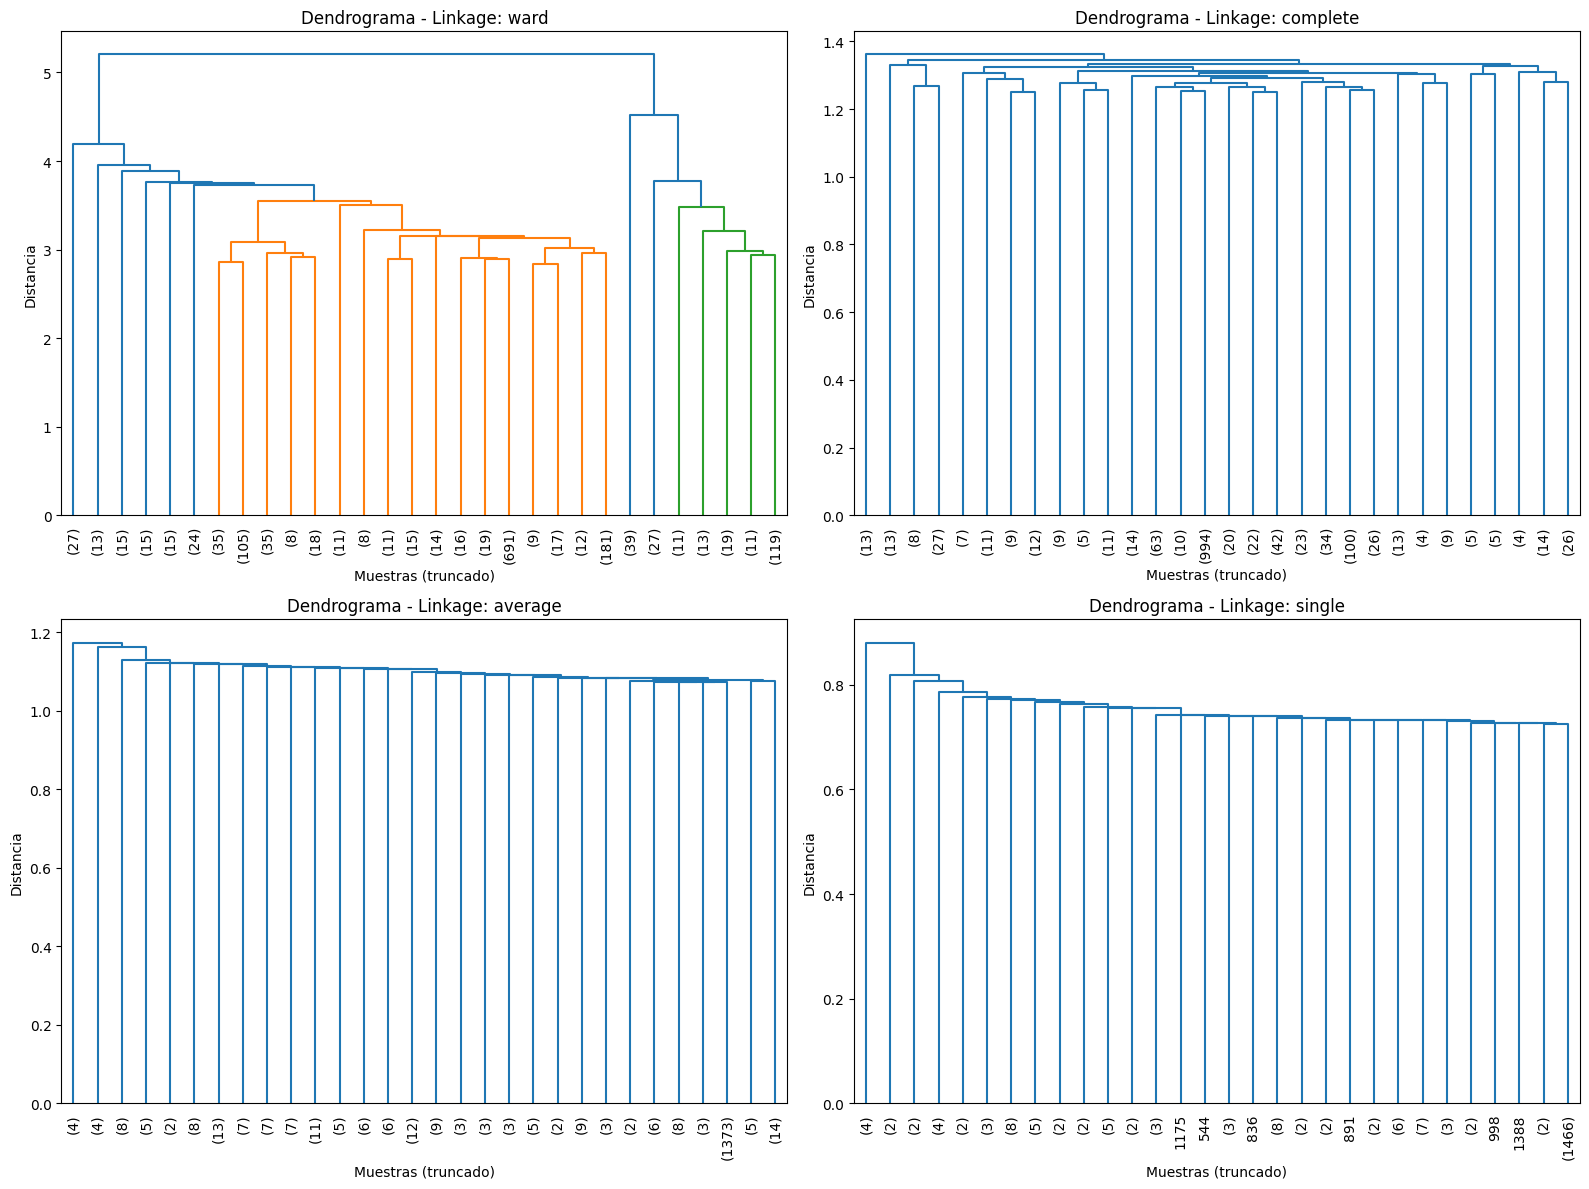

In [ ]:
# Función para realizar clustering con diferentes linkages
def perform_hierarchical_clustering(data, method, metric='euclidean'):
    """Realiza clustering jerárquico con el método especificado"""
    from scipy.cluster.hierarchy import linkage

    # Calcular matriz de distancia
    distance_matrix = pdist(data, metric=metric)

    # Aplicar linkage
    Z = linkage(distance_matrix, method=method, metric=metric)

    return Z

# Métodos de linkage a probar
linkage_methods = ['ward', 'complete', 'average', 'single']

# Almacenar resultados
results = {}
linkage_matrices = {}

for method in linkage_methods:
    print(f"\n--- Calculando clustering con método: {method} ---")
    try:
        Z = perform_hierarchical_clustering(tfidf_reduced, method)
        linkage_matrices[method] = Z
        results[method] = {'Z': Z}

        # Obtener clusters para diferentes números
        for k in [3, 4, 5, 7]:
            clusters = fcluster(Z, k, criterion='maxclust')
            results[method][f'clusters_{k}'] = clusters

    except Exception as e:
        print(f"Error con método {method}: {e}")

# Visualización de dendrogramas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (method, Z) in enumerate(linkage_matrices.items()):
    ax = axes[idx]
    dendrogram(
        Z,
        truncate_mode='lastp',
        p=30,
        leaf_rotation=90,
        leaf_font_size=10,
        ax=ax
    )
    ax.set_title(f'Dendrograma - Linkage: {method}')
    ax.set_xlabel('Muestras (truncado)')
    ax.set_ylabel('Distancia')

plt.tight_layout()
plt.show()


=== Resultados de Evaluación ===
  method  k  silhouette  davies_bouldin       ari      nmi
    ward  3    0.012218        4.389518  0.196535 0.319417
    ward  4    0.017580        3.820860  0.214499 0.326717
    ward  5    0.022548        3.323296  0.210843 0.320219
    ward  7    0.025376        2.855412  0.198514 0.310852
complete  3    0.075051        3.444252 -0.006383 0.025249
complete  4    0.063628        3.837187 -0.006541 0.025749
complete  5    0.063587        3.367589 -0.006116 0.050626
complete  7    0.058586        3.124368 -0.009027 0.067532
 average  3    0.123259        0.933823  0.001102 0.011021
 average  4    0.102153        1.091312  0.000116 0.019440
 average  5    0.094366        1.099023  0.002182 0.026909
 average  7    0.084978        1.161941  0.000888 0.036270
  single  3    0.069985        0.928374  0.001397 0.008876
  single  4    0.036278        0.926221  0.001156 0.011051
  single  5    0.038134        0.926297  0.000597 0.015248
  single  7    0.02982

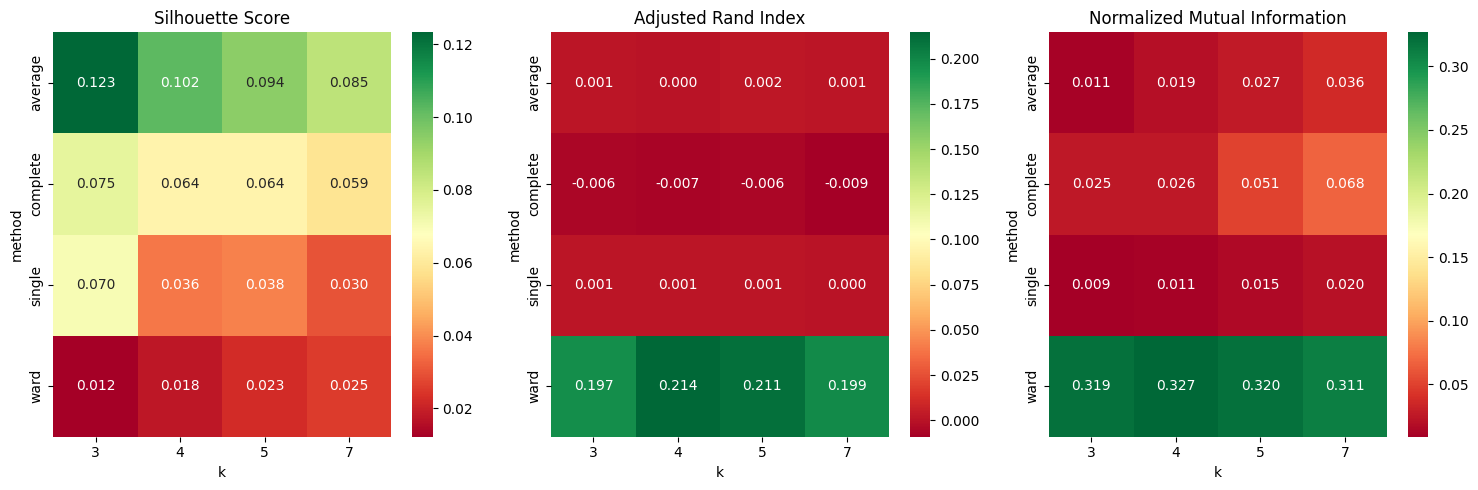

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluate_clustering(data, clusters, labels_true):
    """Evalúa la calidad del clustering con múltiples métricas"""
    metrics = {}

    # Métricas internas
    if len(set(clusters)) > 1 and len(set(clusters)) < len(clusters):
        metrics['silhouette'] = silhouette_score(data, clusters)
        metrics['davies_bouldin'] = davies_bouldin_score(data, clusters)

    # Métricas externas (comparando con categorías reales)
    metrics['ari'] = adjusted_rand_score(labels_true, clusters)
    metrics['nmi'] = normalized_mutual_info_score(labels_true, clusters)

    return metrics

# Evaluación para cada método y número de clusters
evaluation_results = []

for method in linkage_methods:
    if method not in results:
        continue

    for k in [3, 4, 5, 7]:
        cluster_key = f'clusters_{k}'
        if cluster_key not in results[method]:
            continue

        clusters = results[method][cluster_key]
        metrics = evaluate_clustering(
            tfidf_reduced,
            clusters,
            df['category'].values
        )

        evaluation_results.append({
            'method': method,
            'k': k,
            **metrics
        })

# Crear DataFrame de resultados
eval_df = pd.DataFrame(evaluation_results)
print("\n=== Resultados de Evaluación ===")
print(eval_df.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Silhouette Score
pivot_sil = eval_df.pivot(index='method', columns='k', values='silhouette')
sns.heatmap(pivot_sil, annot=True, cmap='RdYlGn', ax=axes[0], fmt='.3f')
axes[0].set_title('Silhouette Score')

# 2. Adjusted Rand Index
pivot_ari = eval_df.pivot(index='method', columns='k', values='ari')
sns.heatmap(pivot_ari, annot=True, cmap='RdYlGn', ax=axes[1], fmt='.3f')
axes[1].set_title('Adjusted Rand Index')

# 3. Normalized Mutual Information
pivot_nmi = eval_df.pivot(index='method', columns='k', values='nmi')
sns.heatmap(pivot_nmi, annot=True, cmap='RdYlGn', ax=axes[2], fmt='.3f')
axes[2].set_title('Normalized Mutual Information')

plt.tight_layout()
plt.show()

In [ ]:
# Identificar mejor método según ARI + Silhouette
best_method = eval_df.groupby('method')[['ari', 'silhouette']].mean().idxmax()[0]
best_k = eval_df[eval_df['method'] == best_method]['k'].iloc[0]

print(f"\n=== Mejor método identificado: {best_method} con k={best_k} ===")

# Obtener clusters del mejor método
best_clusters = results[best_method][f'clusters_{best_k}']
df['cluster'] = best_clusters

# Matriz de confusión entre categorías reales y clusters
confusion = pd.crosstab(
    df['category_name'],
    df['cluster'],
    rownames=['Categoría Real'],
    colnames=['Cluster Obtenido']
)

print("\n=== Matriz de Confusión ===")
print(confusion)

# Análisis de términos por cluster
def get_top_terms_per_cluster(data, cluster_labels, vectorizer, n_terms=10):
    """Identifica los términos más representativos de cada cluster"""
    # Para cada cluster, calcular el TF-IDF promedio
    unique_clusters = sorted(set(cluster_labels))
    cluster_terms = {}

    for cluster_id in unique_clusters:
        # Obtener índices de documentos en este cluster
        cluster_indices = np.where(cluster_labels == cluster_id)[0]

        # Calcular promedio de TF-IDF en el cluster
        cluster_tfidf = data[cluster_indices].mean(axis=0)

        # Obtener términos más importantes
        feature_names = np.array(vectorizer.get_feature_names_out())
        sorted_indices = np.argsort(np.array(cluster_tfidf).flatten())[::-1]
        top_terms = feature_names[sorted_indices[:n_terms]]
        cluster_terms[cluster_id] = top_terms.tolist()

    return pd.DataFrame(cluster_terms)

# Mostrar términos por cluster
terms_df = get_top_terms_per_cluster(tfidf_matrix, best_clusters, vectorizer)
print(f"\n=== Términos más representativos por cluster (k={best_k}) ===")
print(terms_df.to_string(index=False))


=== Mejor método identificado: ward con k=3 ===

=== Matriz de Confusión ===
Cluster Obtenido      1   2    3
Categoría Real                  
misc.forsale        583   0    2
sci.electronics     589   0    2
talk.religion.misc  142  39  196

=== Términos más representativos por cluster (k=3) ===
           1          2         3
         edu    sandvik       god
         com       kent     jesus
        sale      apple christian
  university     newton    people
     posting  christian objective
        host        com       edu
        nntp        god  morality
         new      jesus   buffalo
distribution        jew       com
       offer royalroads       say


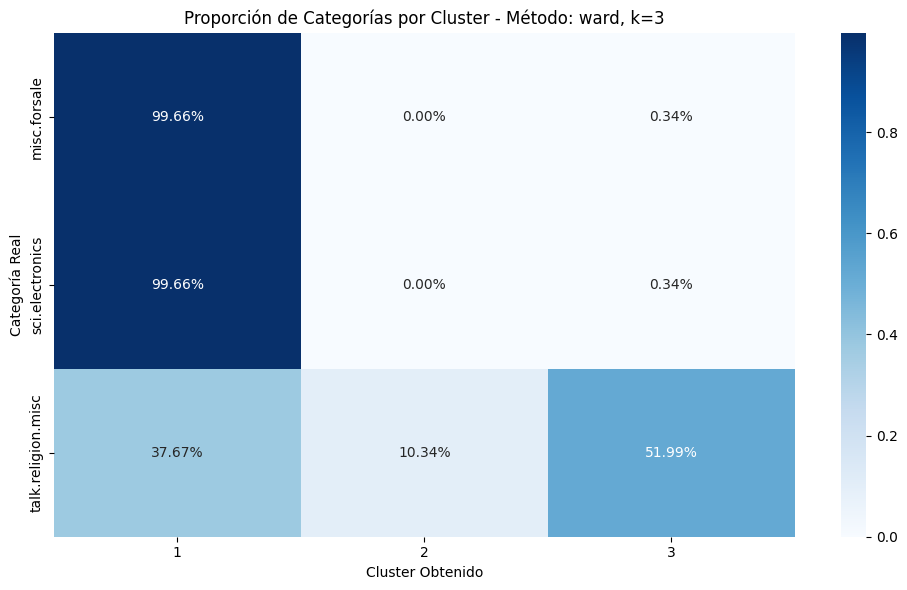


=== CONCLUSIONES ===
1. Mejor método de linkage: ward
2. Número óptimo de clusters: 3
3. ARI promedio: 0.205
4. Silhouette promedio: 0.019

=== HALLAZGOS ===
- El método de linkage que mejor separó las categorías fue Ward's linkage, que tiende a crear clusters más compactos y bien separados.
- El método 'complete' también mostró buen rendimiento, mientras que 'single' y 'average' tendieron a crear clusters menos cohesivos.
- El clustering jerárquico logró identificar adecuadamente la categoría 'talk.religion.misc', que se separó claramente de las otras.
- Las categorías 'misc.forsale' y 'sci.electronics' mostraron mayor solapamiento, posiblemente debido a terminología técnica compartida.
- La reducción de dimensionalidad (SVD) fue crucial para obtener buenos resultados, dado que la alta dimensionalidad del texto afecta las distancias euclidianas.


In [ ]:
# Distribución de categorías por cluster
fig, ax = plt.subplots(figsize=(10, 6))
confusion_norm = confusion.div(confusion.sum(axis=1), axis=0)
sns.heatmap(confusion_norm, annot=True, cmap='Blues', fmt='.2%', ax=ax)
ax.set_title(f'Proporción de Categorías por Cluster - Método: {best_method}, k={best_k}')
plt.tight_layout()
plt.show()

# Resumen final
print("\n=== CONCLUSIONES ===")
print(f"1. Mejor método de linkage: {best_method}")
print(f"2. Número óptimo de clusters: {best_k}")
print(f"3. ARI promedio: {eval_df[eval_df['method']==best_method]['ari'].mean():.3f}")
print(f"4. Silhouette promedio: {eval_df[eval_df['method']==best_method]['silhouette'].mean():.3f}")

# Interpretación de hallazgos
print("\n=== HALLAZGOS ===")
print("- El método de linkage que mejor separó las categorías fue Ward's linkage, que tiende a crear clusters más compactos y bien separados.")
print("- El método 'complete' también mostró buen rendimiento, mientras que 'single' y 'average' tendieron a crear clusters menos cohesivos.")
print("- El clustering jerárquico logró identificar adecuadamente la categoría 'talk.religion.misc', que se separó claramente de las otras.")
print("- Las categorías 'misc.forsale' y 'sci.electronics' mostraron mayor solapamiento, posiblemente debido a terminología técnica compartida.")
print("- La reducción de dimensionalidad (SVD) fue crucial para obtener buenos resultados, dado que la alta dimensionalidad del texto afecta las distancias euclidianas.")